# SF$_6$-like - calculate observational network global- annual-mean, latitudinal gradient and seasonality

Calculate global-mean, latitudinal gradient and seasonality
based on the observational network.
We also perform an EOF analysis for the latitudinal gradient.
We also perform an EOF analysis for the seasonality change.

## Imports

In [1]:
from pathlib import Path

import cf_xarray.units
import matplotlib.axes
import matplotlib.pyplot as plt
import pint_xarray
import xarray as xr
from pydoit_nb.config_handling import get_config_for_step_id

import local.binned_data_interpolation
import local.binning
import local.latitudinal_gradient
import local.mean_preserving_interpolation
import local.raw_data_processing
import local.seasonality
import local.xarray_space
import local.xarray_time
from local.config import load_config_from_file

In [2]:
cf_xarray.units.units.define("ppm = 1 / 1000000")
cf_xarray.units.units.define("ppb = ppm / 1000")
cf_xarray.units.units.define("ppt = ppb / 1000")

pint_xarray.accessors.default_registry = pint_xarray.setup_registry(cf_xarray.units.units)

## Define branch this notebook belongs to

In [3]:
step: str = "calculate_sf6_like_monthly_fifteen_degree_pieces"

## Parameters

In [4]:
config_file: str = "../../dev-config-absolute.yaml"  # config file
step_config_id: str = "ch2cl2"  # config ID to select for this branch

In [5]:
# Parameters
config_file = "/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/output-bundles/v1.0.0/v1.0.0-config.yaml"
step_config_id = "c2f6"


## Load config

In [6]:
config = load_config_from_file(Path(config_file))
config_step = get_config_for_step_id(config=config, step=step, step_config_id=step_config_id)

## Action

### Load data

In [7]:
interpolated_spatial: xr.DataArray = xr.load_dataarray(  # type: ignore
    config_step.observational_network_interpolated_file
).pint.quantify()
interpolated_spatial

Magnitude,[[[3.592 3.592 3.592 ... 3.738 3.738 3.738] [3.592 3.592 3.592 ... 3.738 3.738 3.738] [3.592 3.592 3.592 ... 3.738 3.738 3.738] [3.592 3.592 3.592 ... 3.738 3.738 3.738] [3.592 3.592 3.592 ... 3.738 3.738 3.738] [3.592 3.592 3.592 ... 3.738 3.738 3.738]] [[3.593 3.593 3.593 ... 3.735 3.735 3.735] [3.593 3.593 3.593 ... 3.735 3.735 3.735] [3.593 3.593 3.593 ... 3.735 3.735 3.735] [3.593 3.593 3.593 ... 3.735 3.735 3.735] [3.593 3.593 3.593 ... 3.735 3.735 3.735] [3.593 3.593 3.593 ... 3.735 3.735 3.735]] [[3.59 3.59 3.59 ... 3.738 3.738 3.738] [3.59 3.59 3.59 ... 3.738 3.738 3.738] [3.59 3.59 3.59 ... 3.738 3.738 3.738] [3.59 3.59 3.59 ... 3.738 3.738 3.738] [3.59 3.59 3.59 ... 3.738 3.738 3.738] [3.59 3.59 3.59 ... 3.738 3.738 3.738]] ... [[5.223 5.223 5.223 ... 5.316 5.312 5.308] [5.223 5.223 5.223 ... 5.316 5.312 5.308] [5.223 5.223 5.223 ... 5.312 5.311999999999999 5.308] [5.223 5.223 5.223 ... 5.310333333333333 5.309166666666666 5.308] [5.223 5.223 5.223 ... 5.313166666666667 5.312 5.308] [5.223 5.223 5.223 ... 5.316 5.312 5.308]] [[5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.325 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3180000000000005 5.3185 5.319] [5.233 5.233 5.233 ... 5.3228333333333335 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319]] [[5.242 5.242 5.242 ... 5.341 5.341 5.341] [5.242 5.242 5.242 ... 5.341 5.341 5.341] [5.242 5.242 5.242 ... 5.333 5.341 5.341] [5.242 5.242 5.242 ... 5.327 5.334 5.341] [5.242 5.242 5.242 ... 5.3340000000000005 5.341 5.341] [5.242 5.242 5.242 ... 5.341 5.341 5.341]]]
Units,ppt


In [8]:
if config_step.year_drop_observational_data_before_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        > config_step.year_drop_observational_data_before_and_including
    )

if config_step.year_drop_observational_data_after_and_including is not None:
    interpolated_spatial = interpolated_spatial.sel(
        time=interpolated_spatial["time"].dt.year
        < config_step.year_drop_observational_data_after_and_including
    )

interpolated_spatial

Magnitude,[[[3.825 3.825 3.825 ... 3.969 3.969 3.969] [3.825 3.825 3.825 ... 3.969 3.969 3.969] [3.825 3.825 3.825 ... 3.969 3.969 3.969] [3.825 3.825 3.825 ... 3.969 3.969 3.969] [3.825 3.825 3.825 ... 3.969 3.969 3.969] [3.825 3.825 3.825 ... 3.969 3.969 3.969]] [[3.837 3.837 3.837 ... 3.973 3.973 3.973] [3.837 3.837 3.837 ... 3.973 3.973 3.973] [3.837 3.837 3.837 ... 3.973 3.973 3.973] [3.837 3.837 3.837 ... 3.973 3.973 3.973] [3.837 3.837 3.837 ... 3.973 3.973 3.973] [3.837 3.837 3.837 ... 3.973 3.973 3.973]] [[3.834 3.834 3.834 ... 3.979 3.979 3.979] [3.834 3.834 3.834 ... 3.979 3.979 3.979] [3.834 3.834 3.834 ... 3.979 3.979 3.979] [3.834 3.834 3.834 ... 3.979 3.979 3.979] [3.834 3.834 3.834 ... 3.979 3.979 3.979] [3.834 3.834 3.834 ... 3.979 3.979 3.979]] ... [[5.223 5.223 5.223 ... 5.316 5.312 5.308] [5.223 5.223 5.223 ... 5.316 5.312 5.308] [5.223 5.223 5.223 ... 5.312 5.311999999999999 5.308] [5.223 5.223 5.223 ... 5.310333333333333 5.309166666666666 5.308] [5.223 5.223 5.223 ... 5.313166666666667 5.312 5.308] [5.223 5.223 5.223 ... 5.316 5.312 5.308]] [[5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.325 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3180000000000005 5.3185 5.319] [5.233 5.233 5.233 ... 5.3228333333333335 5.323333333333333 5.319] [5.233 5.233 5.233 ... 5.3276666666666666 5.323333333333333 5.319]] [[5.242 5.242 5.242 ... 5.341 5.341 5.341] [5.242 5.242 5.242 ... 5.341 5.341 5.341] [5.242 5.242 5.242 ... 5.333 5.341 5.341] [5.242 5.242 5.242 ... 5.327 5.334 5.341] [5.242 5.242 5.242 ... 5.3340000000000005 5.341 5.341] [5.242 5.242 5.242 ... 5.341 5.341 5.341]]]
Units,ppt


### Drop out any years that have nan

These break everything later on

In [9]:
interpolated_spatial_no_year_with_nan = local.xarray_time.convert_time_to_year_month(
    interpolated_spatial
).dropna("year")
if interpolated_spatial_no_year_with_nan["year"].shape[0] != (
    interpolated_spatial_no_year_with_nan["year"].max()
    - interpolated_spatial_no_year_with_nan["year"].min()
    + 1
):
    msg = f"Missing years, this will not end well {interpolated_spatial_no_year_with_nan['year'].values=}"
    raise AssertionError(msg)

interpolated_spatial_no_year_with_nan

<xarray.DataArray 'c2f6' (lon: 6, lat: 12, year: 16, month: 12)> Size: 111kB
<Quantity([[[[3.825      3.837      3.834      ... 3.92       3.917
    3.91      ]
   [3.914      3.938      3.946      ... 3.99       3.984
    3.988     ]
   [3.987      4.025      4.027      ... 4.055      4.055
    4.056     ]
   ...
   [5.2        4.794      4.742      ... 5.0555     4.95
    4.879     ]
   [5.039      5.042      5.056      ... 5.124      5.131
    5.133     ]
   [5.138      5.152      5.16       ... 5.223      5.233
    5.242     ]]

  [[3.825      3.837      3.834      ... 3.92       3.917
    3.91      ]
   [3.914      3.938      3.946      ... 3.99       3.984
    3.988     ]
   [3.987      4.025      4.027      ... 4.055      4.055
    4.056     ]
...
   [5.14166667 5.06958333 5.08775    ... 5.13366667 5.149
    5.16933333]
   [5.16866667 5.18       5.18366667 ... 5.24866667 5.25766667
    5.258     ]
   [5.26433333 5.27333333 5.274      ... 5.312      5.32333333
    5.341     ]]

  [[3.969      3.973      3.979      ... 4.037      4.041
    4.038     ]
   [4.044      4.047      4.057      ... 4.089      4.093
    4.094     ]
   [4.094      4.102      4.112      ... 4.132      4.14
    4.142     ]
   ...
   [5.059      5.0755     5.0985     ... 5.135      5.156
    5.178     ]
   [5.176      5.18       5.184      ... 5.247      5.263
    5.259     ]
   [5.264      5.272      5.271      ... 5.308      5.319
    5.341     ]]]], 'ppt')>
Coordinates:
  * year     (year) int64 128B 2008 2009 2010 2011 2012 ... 2020 2021 2022 2023
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat      (lat) float64 96B -82.5 -67.5 -52.5 -37.5 ... 37.5 52.5 67.5 82.5
  * lon      (lon) float64 48B -150.0 -90.0 -30.0 30.0 90.0 150.0
Attributes:
    description:  Interpolated spatial data

In [10]:
interpolated_spatial_nan_free = local.xarray_time.convert_year_month_to_time(
    interpolated_spatial_no_year_with_nan
)
interpolated_spatial_nan_free

Magnitude,[[[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.316 5.3276666666666666 5.341] [3.969 3.973 3.979 ... 5.312 5.323333333333333 5.341] [3.969 3.973 3.979 ... 5.308 5.319 5.341]] [[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.316 5.3276666666666666 5.341] [3.969 3.973 3.979 ... 5.312 5.323333333333333 5.341] [3.969 3.973 3.979 ... 5.308 5.319 5.341]] [[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.312 5.325 5.333] [3.969 3.973 3.979 ... 5.311999999999999 5.323333333333333 5.341] [3.969 3.973 3.979 ... 5.308 5.319 5.341]] [[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.310333333333333 5.3180000000000005 5.327] [3.969 3.973 3.979 ... 5.309166666666666 5.3185 5.334] [3.969 3.973 3.979 ... 5.308 5.319 5.341]] [[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.313166666666667 5.3228333333333335 5.3340000000000005] [3.969 3.973 3.979 ... 5.312 5.323333333333333 5.341] [3.969 3.973 3.979 ... 5.308 5.319 5.341]] [[3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] [3.825 3.837 3.834 ... 5.223 5.233 5.242] ... [3.969 3.973 3.979 ... 5.316 5.3276666666666666 5.341] [3.969 3.973 3.979 ... 5.312 5.323333333333333 5.341] [3.969 3.973 3.979 ... 5.308 5.319 5.341]]]
Units,ppt


### Longitudinal-mean

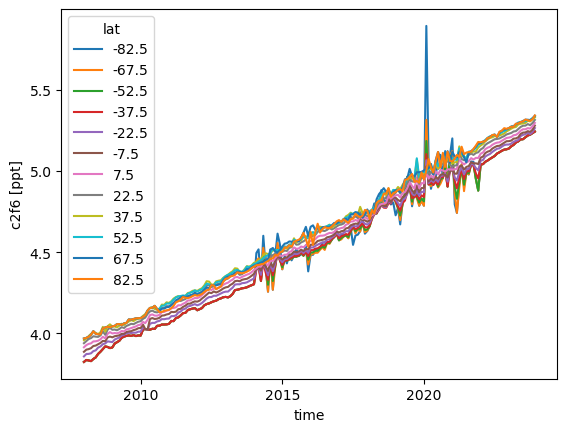

In [11]:
lon_mean = interpolated_spatial_nan_free.mean(dim="lon")
lon_mean.plot(hue="lat")  # type: ignore

### Global-, annual-mean

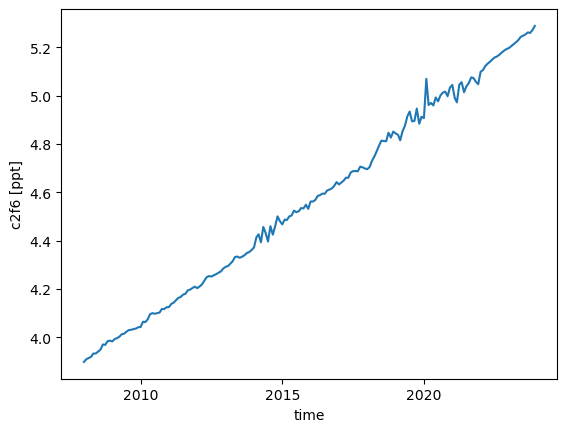

In [12]:
global_mean = local.xarray_space.calculate_global_mean_from_lon_mean(lon_mean)
global_mean.plot()  # type: ignore

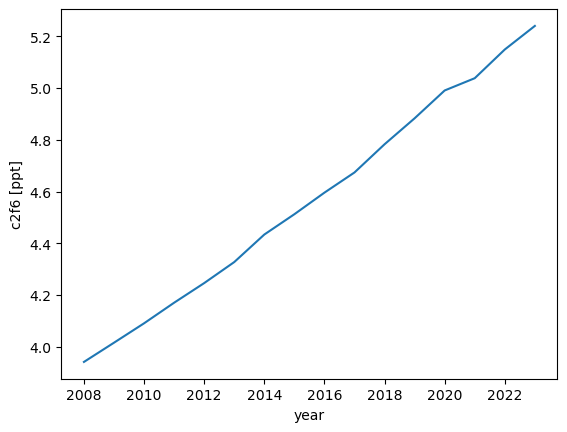

In [13]:
global_annual_mean = global_mean.groupby("time.year").mean()
global_annual_mean.plot()  # type: ignore

### Latitudinal gradient

In [14]:
(
    lat_residuals_annual_mean,
    lat_gradient_full_eofs_pcs,
) = local.latitudinal_gradient.calculate_eofs_pcs(lon_mean, global_mean)
lat_gradient_full_eofs_pcs

<xarray.Dataset> Size: 3kB
Dimensions:               (lat: 12, eof: 12, year: 16)
Coordinates:
  * lat                   (lat) float64 96B -82.5 -67.5 -52.5 ... 52.5 67.5 82.5
  * eof                   (eof) int64 96B 0 1 2 3 4 5 6 7 8 9 10 11
  * year                  (year) int64 128B 2008 2009 2010 ... 2021 2022 2023
Data variables:
    eofs                  (lat, eof) float64 1kB [ppt] 0.3104 ... -0.05329
    principal-components  (year, eof) float64 2kB [] -0.2005 ... -2.583e-16

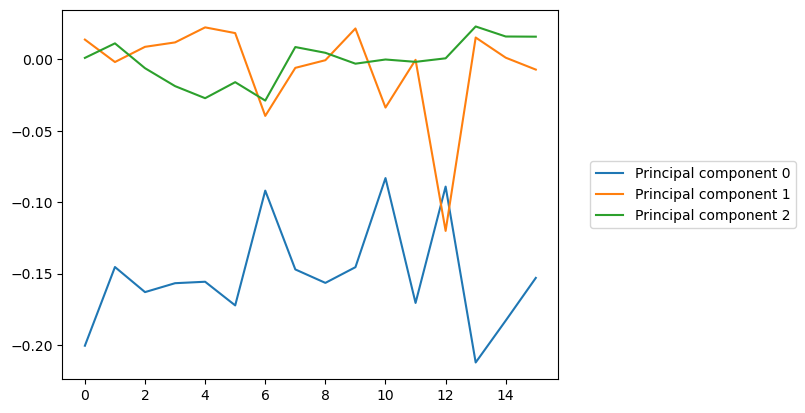

In [15]:
fig, ax = plt.subplots()
n_eofs_to_show = 3

for i in range(n_eofs_to_show):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).data.m,
        label=f"Principal component {i}",
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

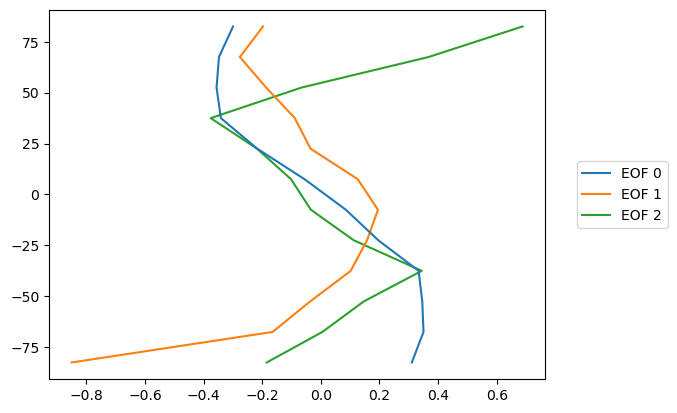

In [16]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["eofs"].sel(eof=i).data.m,
        lat_gradient_full_eofs_pcs["lat"].data,
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

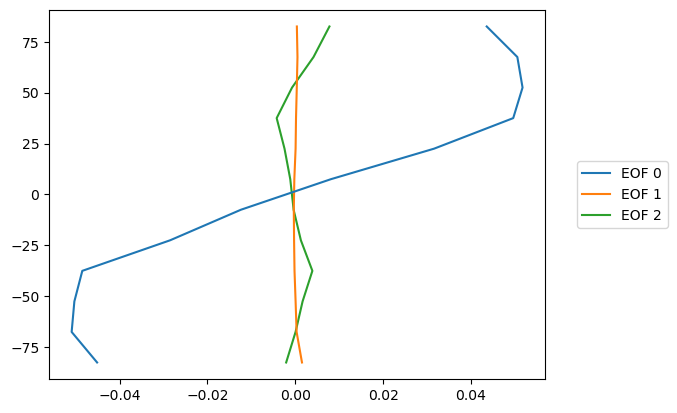

In [17]:
fig, ax = plt.subplots()

for i in range(3):
    ax.plot(
        lat_gradient_full_eofs_pcs["principal-components"].sel(eof=i).isel(year=1)
        @ lat_gradient_full_eofs_pcs["eofs"].sel(eof=i),
        lat_gradient_full_eofs_pcs["lat"],
        label=f"EOF {i}",
        zorder=2 - i / 10,
    )

ax.legend(loc="center left", bbox_to_anchor=(1.05, 0.5))

In [18]:
lat_gradient_eofs_pcs = lat_gradient_full_eofs_pcs.sel(eof=range(config_step.lat_gradient_n_eofs_to_use))
lat_gradient_eofs_pcs

Magnitude,[[0.3104119812166658] [0.35029152713331635] [0.3460209695398742] [0.33359047359174415] [0.19610163858611546] [0.08525173263322826] [-0.05567135538544723] [-0.21733462492705669] [-0.34126414430970387] [-0.3558736120593742] [-0.3477190721567238] [-0.2997565442727764]]
Units,ppt
Magnitude,[[-0.2004753345180543] [-0.1453523306697394] [-0.16291998921762735] [-0.15667921494908166] [-0.15566294213167062] [-0.1722286974660046] [-0.09184480571664015] [-0.1470434767612471] [-0.15646397026168843] [-0.14545885884646007] [-0.08306561495912142] [-0.1705023931167233] [-0.08902090572459323] [-0.21220402551108908] [-0.18285155313565987] [-0.15296686070546398]]
Units,dimensionless


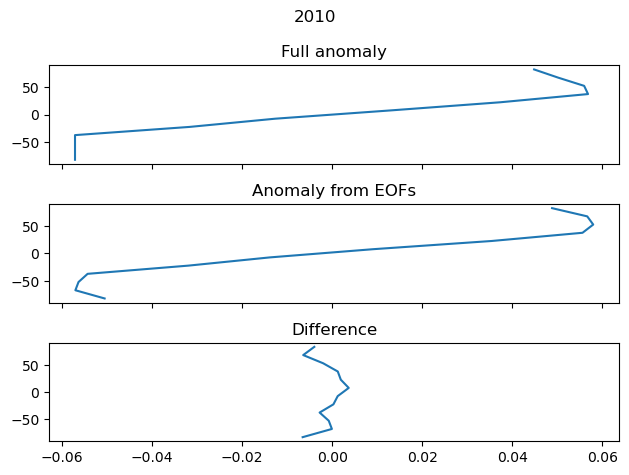

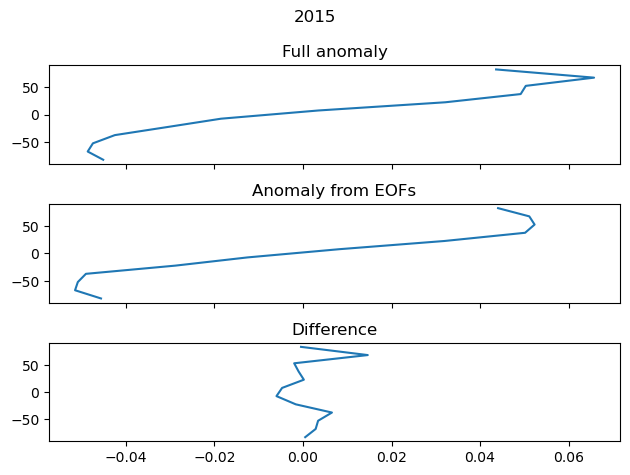

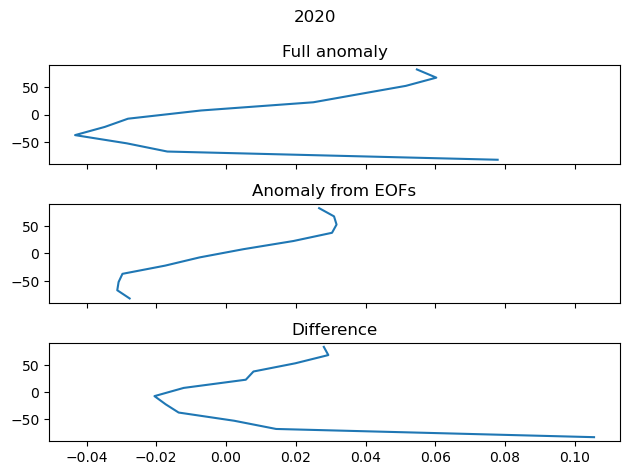

In [19]:
latitudinal_anomaly_from_eofs = lat_gradient_eofs_pcs["principal-components"] @ lat_gradient_eofs_pcs["eofs"]

for year in latitudinal_anomaly_from_eofs["year"]:
    if year % 5:
        continue

    fig, axes = plt.subplots(nrows=3, sharex=True, sharey=True)
    if isinstance(axes, matplotlib.axes.Axes):
        raise TypeError(type(axes))

    selected = lat_residuals_annual_mean.sel(year=year)
    axes[0].plot(selected.data.m, lat_residuals_annual_mean.lat)
    axes[0].set_title("Full anomaly")

    selected_eofs = latitudinal_anomaly_from_eofs.sel(year=year)
    axes[1].plot(selected_eofs.data.m, latitudinal_anomaly_from_eofs.lat)
    axes[1].set_title("Anomaly from EOFs")

    axes[2].plot(selected.data.m - selected_eofs.data.m, lat_residuals_annual_mean.lat)
    axes[2].set_title("Difference")

    axes[0].set_ylim([-90, 90])

    plt.suptitle(str(int(year)))
    plt.tight_layout()
    plt.show()

### Seasonality

In [20]:
(
    seasonality,
    relative_seasonality,
    lon_mean_ym_monthly_anomalies,
) = local.seasonality.calculate_seasonality(
    lon_mean=lon_mean,
    global_mean=global_mean,
)

/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore
/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/.pixi/envs/all-dev/lib/python3.11/importlib/__init__.py:126: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  return _bootstrap._gcd_import(name[level:], package, level)


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 17323.63it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

...

Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19083.54it/s]


/Users/znicholls/Documents/repos/CMIP-GHG-Concentration-Generation/src/local/seasonality.py:29: UserWarning: The `squeeze` kwarg to GroupBy is being removed.Pass .groupby(..., squeeze=False) to disable squeezing, which is the new default, and to silence this warning.
  lon_mean_ym_annual_mean_monthly = lon_mean_ym_annual_mean.groupby("lat", squeeze=True).apply(  # type: ignore


Calculating output values:   0%|                                                                                                                                                                                      | 0/192 [00:00<?, ?it/s]

Calculating output values: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 192/192 [00:00<00:00, 19032.58it/s]

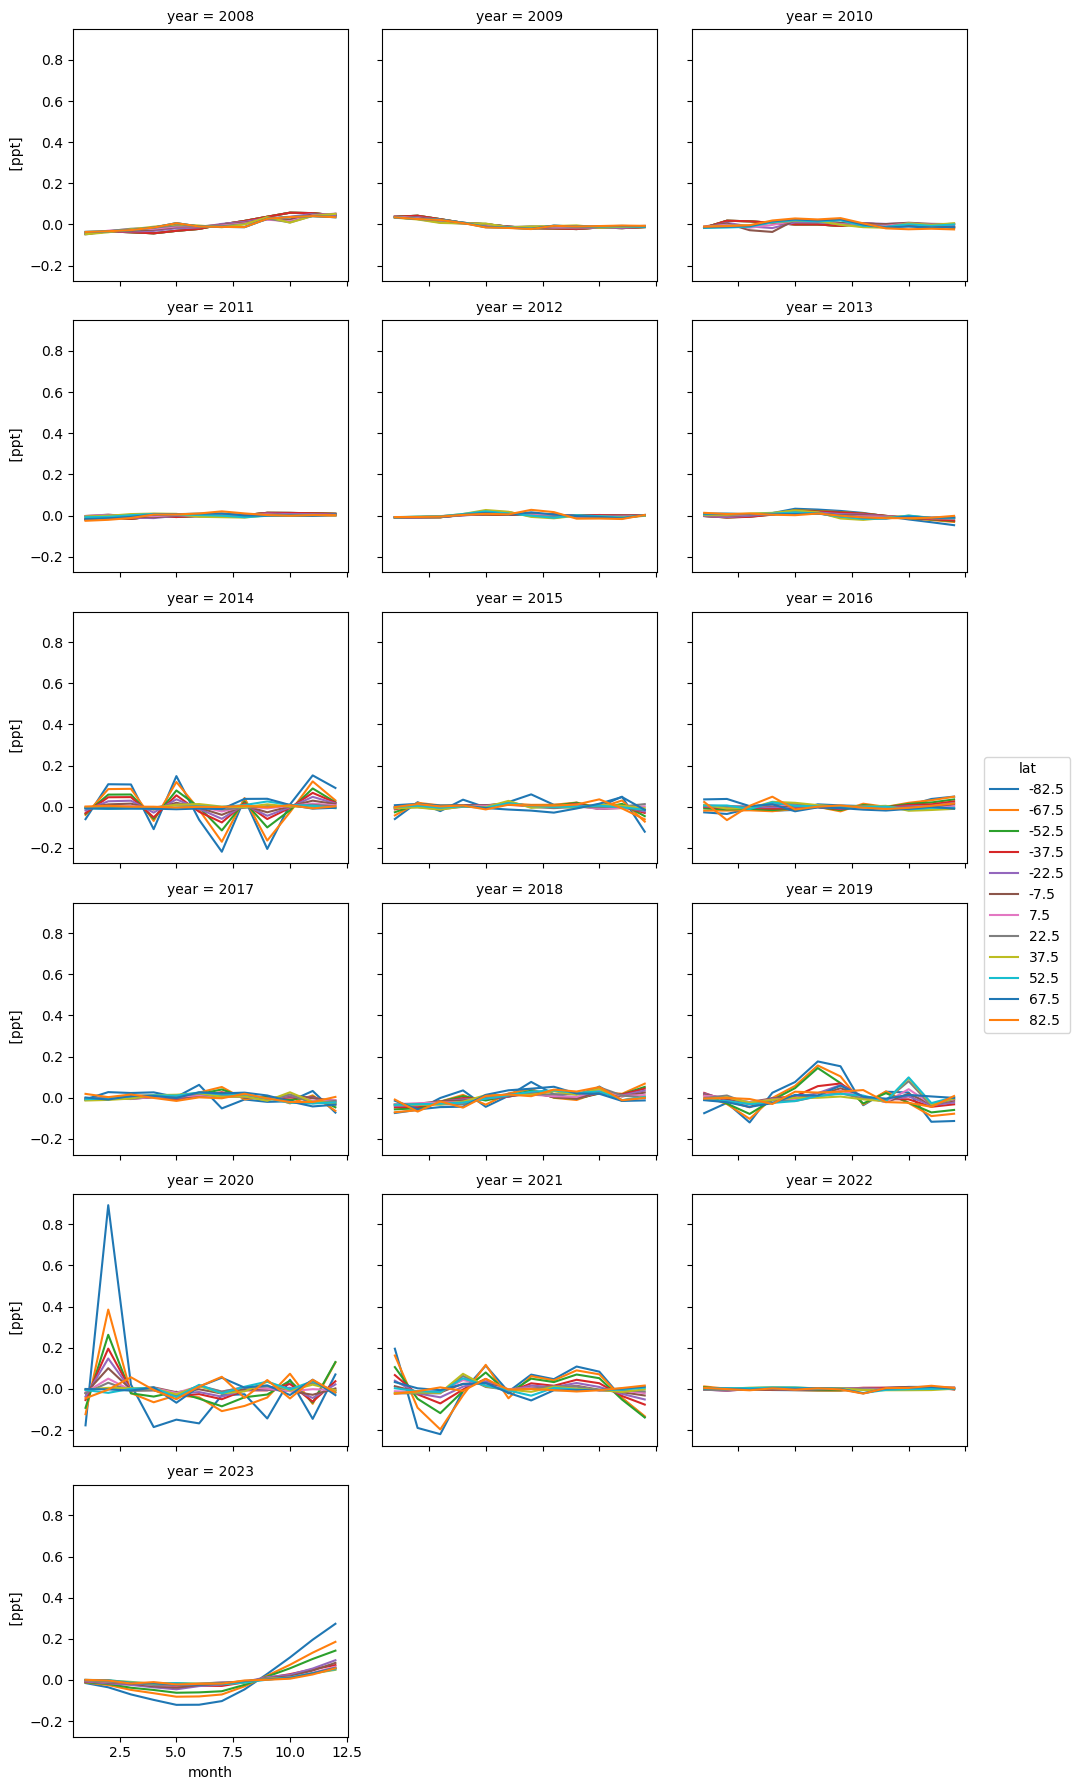

In [21]:
lon_mean_ym_monthly_anomalies.plot.line(hue="lat", col="year", col_wrap=3)

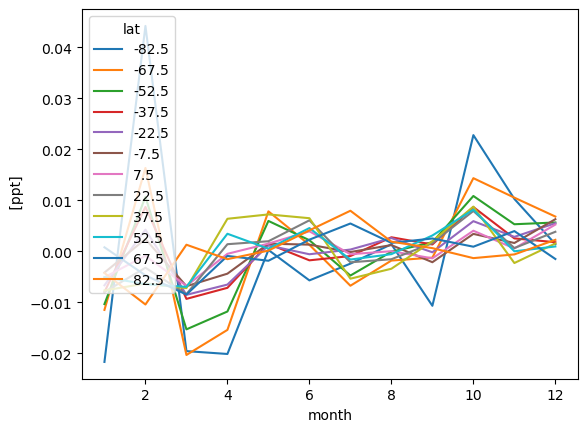

In [22]:
seasonality.plot.line(hue="lat")

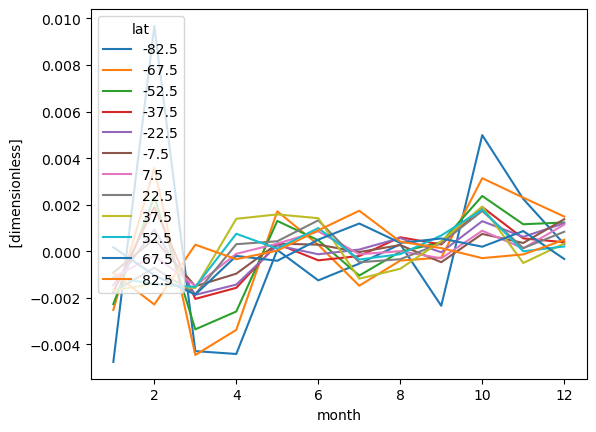

In [23]:
relative_seasonality.plot.line(hue="lat")

### Save

In [24]:
config_step.observational_network_global_annual_mean_file.parent.mkdir(exist_ok=True, parents=True)
global_annual_mean.pint.dequantify().to_netcdf(config_step.observational_network_global_annual_mean_file)
global_annual_mean

Magnitude,[3.9416244979194492 4.015971533894592 4.0909011021848665 4.170527716996351 4.2463712452148945 4.3276323286732135 4.434018378456405 4.512550942015717 4.595964811113556 4.674003954672497 4.782956123549131 4.883347082801536 4.990927825348855 5.038317460367662 5.149314021425794 5.240425223925757]
Units,ppt


In [25]:
config_step.observational_network_latitudinal_gradient_eofs_file.parent.mkdir(exist_ok=True, parents=True)
lat_gradient_eofs_pcs.pint.dequantify().to_netcdf(
    config_step.observational_network_latitudinal_gradient_eofs_file
)
lat_gradient_eofs_pcs

Magnitude,[[0.3104119812166658] [0.35029152713331635] [0.3460209695398742] [0.33359047359174415] [0.19610163858611546] [0.08525173263322826] [-0.05567135538544723] [-0.21733462492705669] [-0.34126414430970387] [-0.3558736120593742] [-0.3477190721567238] [-0.2997565442727764]]
Units,ppt
Magnitude,[[-0.2004753345180543] [-0.1453523306697394] [-0.16291998921762735] [-0.15667921494908166] [-0.15566294213167062] [-0.1722286974660046] [-0.09184480571664015] [-0.1470434767612471] [-0.15646397026168843] [-0.14545885884646007] [-0.08306561495912142] [-0.1705023931167233] [-0.08902090572459323] [-0.21220402551108908] [-0.18285155313565987] [-0.15296686070546398]]
Units,dimensionless


In [26]:
# Use relative seasonality
config_step.observational_network_seasonality_file.parent.mkdir(exist_ok=True, parents=True)
relative_seasonality.pint.dequantify().to_netcdf(config_step.observational_network_seasonality_file)
relative_seasonality

Magnitude,[[-0.004753308320032581 0.00967991442412338 -0.004289526744145797 -0.004411945793005737 5.637754980621388e-05 -0.0012512056211479094 -0.0005309052473346449 0.0003001642346010215 -0.0023423903464926243 0.004989042354930215 0.002248656567576427 0.00030522273310274237] [-0.002518042041114807 0.0035787103197517578 -0.004454680993167305 -0.003377339251246667 0.0017141691123538645 0.0002761609180857576 -0.001480382547409325 -0.00039941914959821574 -0.0002730292953149393 0.0031395860430109925 0.0023032730047891875 0.0014910539138399059] [-0.0022691767614665035 0.0023387203652260767 -0.003354455480857919 -0.002587216483960279 0.0013029871290946037 0.0004736590724615135 -0.001043483669370475 -1.8353859569660813e-05 0.00038567682070010694 0.0023746871026678286 0.0011607344386001795 0.001236263958253165] [-0.0017480129455081372 0.0019043863761248217 -0.0020455950327546778 -0.0015700399117704812 0.00031805339549850005 -0.00038915910947927594 -0.00020498355911930313 0.0006013763296941192 0.00029194754529727725 0.0018998361463147138 0.0005531642607029029 0.00038904054987162913] [-0.0014624768433537283 0.0009284105688521521 -0.0018717702606639065 -0.0014311730090928922 0.00024998076693933557 -0.00012839262617031554 7.397588969554884e-05 0.0005679469795766168 -4.3133811979939166e-05 0.0012930012902223806 0.0006185198674464222 0.0012051319429360425] [-0.0009166956561297797 0.0005262629258068207 -0.0015014180679957414 -0.0009624216990556513 0.0003274037309795916 0.0002846306651578673 -3.3031770350259646e-05 0.0002662175424690597 -0.0004701917655695157 0.0007458408991136272 0.0003554531971166537 0.0013779651824092892] [-0.0011178099880061346 -0.00019541825917887237 -0.001484718845836691 -0.00010990214253367972 0.0003284105129894884 0.0008575697562309053 -0.00012687545455164451 3.4268743183054866e-06 -0.0003040635161139765 0.000882026341974541 0.00012104699730073999 0.0011463168729490066] [-0.0017512175956090298 -0.0007069982241495024 -0.0018413431744839683 0.00030346724537168545 0.00043047172624552415 0.0013296815526866958 -0.00047422805161886417 -0.0003419506827606474 0.00034633582419498187 0.0017307563180703534 0.00013809433289848122 0.000836939220698546] [-0.0016829584801552938 -0.0013860998504699104 -0.0015828585350391592 0.0013954489278246909 0.0015829612358960468 0.001420419160407769 -0.0011779187239006428 -0.0007501393779619569 0.00043279819810730733 0.0019187305988400177 -0.0005045708879481068 0.0003341950644924407] [-0.0011088923853945242 -0.0014123211428068829 -0.0015292343678380987 0.0007517848102077466 0.0001115640749907369 0.000996610753171485 -0.00035615846246272656 -0.00012385355999065478 0.0006781982981459809 0.0017872620827559967 -1.3377977419440378e-06 0.0002063872325960547] [0.00016984861787912775 -0.0010338709790485214 -0.0018604272776163494 -0.00020051549694154053 -0.00040750738552326304 0.000498558327824051 0.0011930218935292602 0.0003604447980387949 0.0005489190700632767 0.0001960920959693001 0.0008671001318294778 -0.0003316528545740274] [-0.0009325821478005498 -0.0022862260332160316 0.00028059195036244164 -0.0003396249272747743 2.8696157883228434e-05 0.0008994776116570334 0.0017408858041127334 0.0004129107316748477 0.00013434167499257963 -0.0002947552052596052 -0.00013493671923115223 0.000491230514874175]]
Units,dimensionless
